In [14]:
from collections import defaultdict

import gymnasium as gym
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm


obs is the observation — Gymnasium's term for the state the agent perceives at this timestep. Here it's typed tuple[int, int, bool]

In [11]:
class BlackjackAgent:
    def __init__(
        self,
        env: gym.Env, # The training environment
        learning_rate: float, # How quickly to update Q-values (0-1)
        initial_epsilon: float, # Starting exploration rate (usually 1.0)
        epsilon_decay: float, # How much to reduce epsilon each episode
        final_epsilon: float, # Minimum exploration rate (usually 0.1)
        discount_factor: float = 0.95, # How much to value future rewards (0-1)
    ):
        self.env = env
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))
        self.lr = learning_rate
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.training_error = []
        self.discount_factor = discount_factor

    def get_action(self, obs: tuple[int, int, bool]) -> int:
        return self.env.action_space.sample() if np.random.random() < self.epsilon else int(np.argmax(self.q_values[obs]))

    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        # (Bellman equation) how good a situation is = what you get right now + how good things look after that
        target = reward + self.discount_factor * future_q_value
        # How wrong was our current estimate?
        temporal_difference = target - self.q_values[obs][action]
        # Update our estimate in the direction of the error
        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

Bellman equation in action - it says the value of a state-action pair should equal the immediate reward plus the discounted value of the best next action.

In [51]:
learning_rate = 0.01        # How fast to learn (higher = faster but less stable)
n_episodes = 100_000    # Number of hands to practice
start_epsilon = 1.0         # Start with 100% random actions
epsilon_decay = .1  # Reduce exploration over time
final_epsilon = 0.1         # Always keep some exploration

In [52]:
env = gym.make("Blackjack-v1", sab=False)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

In [53]:
agent = BlackjackAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [54]:
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False
    
    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        agent.update(obs, action, reward, terminated, next_obs)
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 23705.50it/s]


In [15]:
def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

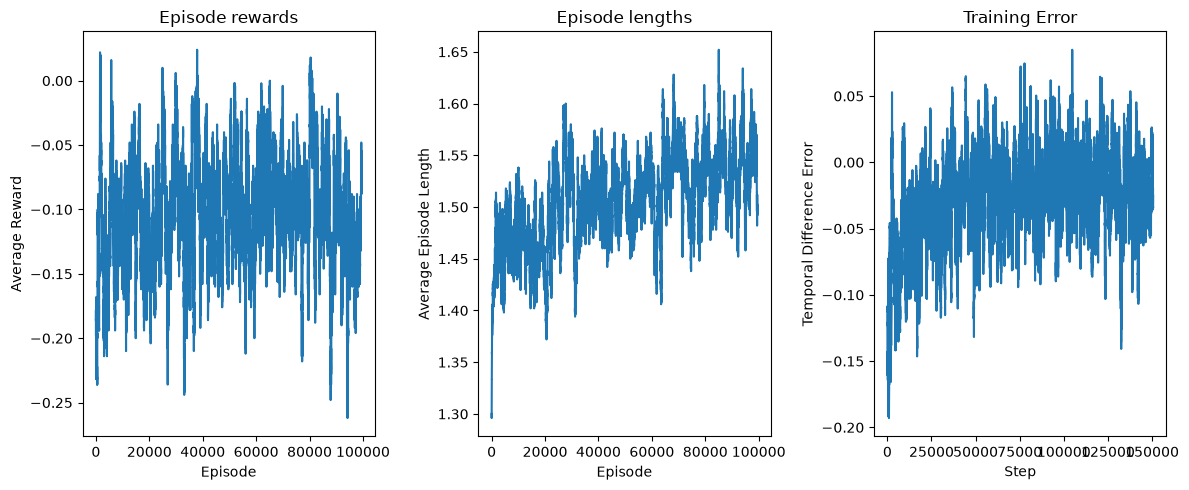

In [55]:
# Smooth over a 500-episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

In [56]:
# Test the trained agent
def test_agent(agent, env, num_episodes=1000):
    """Test agent performance without learning or exploration."""
    total_rewards = []

    # Temporarily disable exploration for testing
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0  # Pure exploitation

    for _ in range(num_episodes):
        obs, info = env.reset()
        episode_reward = 0
        done = False

        while not done:
            action = agent.get_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            done = terminated or truncated

        total_rewards.append(episode_reward)

    # Restore original epsilon
    agent.epsilon = old_epsilon

    win_rate = np.mean(np.array(total_rewards) > 0)
    average_reward = np.mean(total_rewards)

    print(f"Test Results over {num_episodes} episodes:")
    print(f"Win Rate: {win_rate:.1%}")
    print(f"Average Reward: {average_reward:.3f}")
    print(f"Standard Deviation: {np.std(total_rewards):.3f}")

# Test your agent
test_agent(agent, env)

Test Results over 1000 episodes:
Win Rate: 46.3%
Average Reward: -0.004
Standard Deviation: 0.964
